In [21]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

In [22]:
np.random.seed(0)
n = 15
x = np.linspace(0,10,n) + np.random.randn(n)/5
y = np.sin(x)+x/6 + np.random.randn(n)/10


X_train, X_test, y_train, y_test = train_test_split(x, y, random_state=0)

# You can use this function to help you visualize the dataset by
# plotting a scatterplot of the data points
# in the training and test sets.
def part1_scatter():
    import matplotlib.pyplot as plt
    %matplotlib notebook
    plt.figure()
    plt.scatter(X_train, y_train, label='training data')
    plt.scatter(X_test, y_test, label='test data')
    plt.legend(loc=4);
    
    
# NOTE: Uncomment the function below to visualize the data, but be sure 
# to **re-comment it before submitting this assignment to the autograder**.   
# part1_scatter()

In [23]:
def answer_one():
    from sklearn.linear_model import LinearRegression
    from sklearn.preprocessing import PolynomialFeatures
    
    result = np.zeros((4,100))
    pred = np.linspace(0, 10, 100)
    deg = [1, 3, 6, 9]
    index = 0
    for i in deg:
        x_poly = PolynomialFeatures(degree = i)
        x_f_poly = x_poly.fit_transform(X_train.reshape(11, 1))
        linreg = LinearRegression().fit(x_f_poly, y_train)
        y = linreg.predict(x_poly.fit_transform(pred.reshape(100,1)))
        result[index,:] = y
        index+=1
    return result
answer_one()

array([[ 2.53040195e-01,  2.69201547e-01,  2.85362899e-01,
         3.01524251e-01,  3.17685603e-01,  3.33846955e-01,
         3.50008306e-01,  3.66169658e-01,  3.82331010e-01,
         3.98492362e-01,  4.14653714e-01,  4.30815066e-01,
         4.46976417e-01,  4.63137769e-01,  4.79299121e-01,
         4.95460473e-01,  5.11621825e-01,  5.27783177e-01,
         5.43944529e-01,  5.60105880e-01,  5.76267232e-01,
         5.92428584e-01,  6.08589936e-01,  6.24751288e-01,
         6.40912640e-01,  6.57073992e-01,  6.73235343e-01,
         6.89396695e-01,  7.05558047e-01,  7.21719399e-01,
         7.37880751e-01,  7.54042103e-01,  7.70203454e-01,
         7.86364806e-01,  8.02526158e-01,  8.18687510e-01,
         8.34848862e-01,  8.51010214e-01,  8.67171566e-01,
         8.83332917e-01,  8.99494269e-01,  9.15655621e-01,
         9.31816973e-01,  9.47978325e-01,  9.64139677e-01,
         9.80301028e-01,  9.96462380e-01,  1.01262373e+00,
         1.02878508e+00,  1.04494644e+00,  1.06110779e+0

<IPython.core.display.Javascript object>


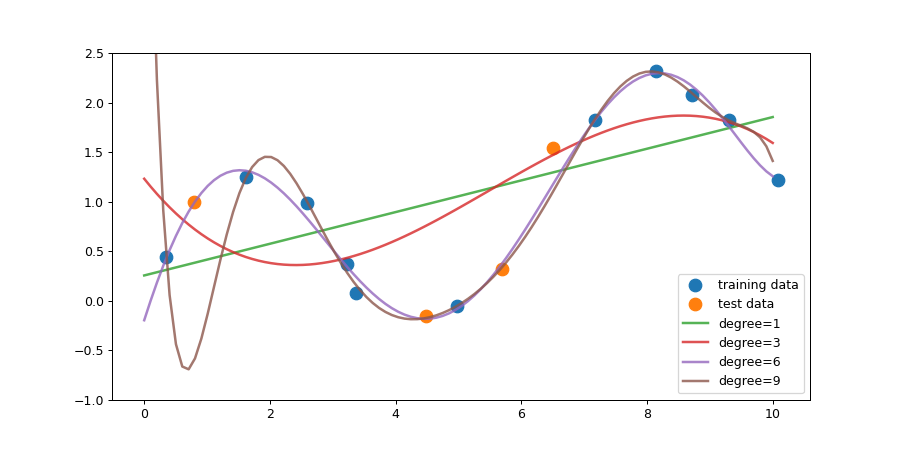

In [24]:
# feel free to use the function plot_one() to replicate the figure 
# from the prompt once you have completed question one
def plot_one(degree_predictions):
    import matplotlib.pyplot as plt
    %matplotlib notebook
    plt.figure(figsize=(10,5))
    plt.plot(X_train, y_train, 'o', label='training data', markersize=10)
    plt.plot(X_test, y_test, 'o', label='test data', markersize=10)
    for i,degree in enumerate([1,3,6,9]):
        plt.plot(np.linspace(0,10,100), degree_predictions[i], alpha=0.8, lw=2, label='degree={}'.format(degree))
    plt.ylim(-1,2.5)
    plt.legend(loc=4)
plot_one(answer_one())

In [26]:
def answer_two():

    from sklearn.linear_model import LinearRegression
    from sklearn.preprocessing import PolynomialFeatures
    from sklearn.metrics.regression import r2_score
    
    r2_train = np.zeros(10)
    r2_test = np.zeros(10)
    
    # Your code here
    for i in range(10):
        poly = PolynomialFeatures(degree=i)
        
        # Train and score x_train
        X_poly = poly.fit_transform(X_train.reshape(11,1))
        lin = LinearRegression().fit(X_poly, y_train)        
        r2_train[i] = lin.score(X_poly, y_train)
        
        # Score x_test (do not train)
        X_test_poly = poly.fit_transform(X_test.reshape(4,1))
        r2_test[i] = lin.score(X_test_poly, y_test)
        
    return (r2_train, r2_test)
answer_two()

(array([0.        , 0.42924578, 0.4510998 , 0.58719954, 0.91941945,
        0.97578641, 0.99018233, 0.99352509, 0.99637545, 0.99803706]),
 array([-0.47808642, -0.45237104, -0.06856984,  0.00533105,  0.73004943,
         0.87708301,  0.9214094 ,  0.92021504,  0.6324795 , -0.64524777]))

In [27]:
def answer_three():
    r2_train, r2_test = answer_two()
    
    diff = (r2_train - r2_test)
    
    sor = []
    for i in range(0, len(diff)):
        sor.append([i, diff[i]])
    
    diff_sorted = sorted(sor, key = lambda x: x[1])
    # print(diff_sorted)
    
    best = diff_sorted[0]
    over = diff_sorted[9]
    
    train_list = []
    for i in range(0, len(r2_train)):
        train_list.append([i, r2_train[i]])
    
    under_sorted = sorted(train_list, key = lambda x: x[1])
    # print(under_sorted)
    under = under_sorted[0]
    
    
    return (under[0], over[0], best[0])
answer_three()

(0, 9, 6)

In [28]:
def answer_four():
    from sklearn.linear_model import LinearRegression
    from sklearn.preprocessing import PolynomialFeatures
    from sklearn.linear_model import Lasso
    
    poly = PolynomialFeatures(degree = 12)
    x_poly = poly.fit_transform(X_train.reshape(11, 1))
    X_test_poly = poly.fit_transform(X_test.reshape(4,1))
    
    # Linear Regression: 
    linreg = LinearRegression().fit(x_poly, y_train) 
    LinearRegression_R2_test_score = linreg.score(X_test_poly, y_test)
    
    lasso = Lasso(alpha=0.01, max_iter=10000).fit(x_poly, y_train)
    Lasso_R2_test_score = lasso.score(X_test_poly, y_test)
    
    return (LinearRegression_R2_test_score, Lasso_R2_test_score)
answer_four()

C:\Users\Poornartha Sawant\anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:476: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.3556421695889839, tolerance: 0.00068949825403828
  positive)


(-4.311980550434311, 0.8406625614750349)

## Part 2 - Classification

Here is an application of machine learning that could save your life! For this section of the assignment
we will be working with the [UCI Mushroom Data Set](http://archive.ics.uci.edu/ml/datasets/Mushroom?ref=datanews.io) stored 
in `readonly/mushrooms.csv`. The data will be used to train a model to predict whether or not a mushroom is poisonous. T
he following attributes are provided:

*Attribute Information:*

1. cap-shape: bell=b, conical=c, convex=x, flat=f, knobbed=k, sunken=s 
2. cap-surface: fibrous=f, grooves=g, scaly=y, smooth=s 
3. cap-color: brown=n, buff=b, cinnamon=c, gray=g, green=r, pink=p, purple=u, red=e, white=w, yellow=y 
4. bruises?: bruises=t, no=f 
5. odor: almond=a, anise=l, creosote=c, fishy=y, foul=f, musty=m, none=n, pungent=p, spicy=s 
6. gill-attachment: attached=a, descending=d, free=f, notched=n 
7. gill-spacing: close=c, crowded=w, distant=d 
8. gill-size: broad=b, narrow=n 
9. gill-color: black=k, brown=n, buff=b, chocolate=h, gray=g, green=r, orange=o, pink=p, purple=u, red=e, white=w, yellow=y 
10. stalk-shape: enlarging=e, tapering=t 
11. stalk-root: bulbous=b, club=c, cup=u, equal=e, rhizomorphs=z, rooted=r, missing=? 
12. stalk-surface-above-ring: fibrous=f, scaly=y, silky=k, smooth=s 
13. stalk-surface-below-ring: fibrous=f, scaly=y, silky=k, smooth=s 
14. stalk-color-above-ring: brown=n, buff=b, cinnamon=c, gray=g, orange=o, pink=p, red=e, white=w, yellow=y 
15. stalk-color-below-ring: brown=n, buff=b, cinnamon=c, gray=g, orange=o, pink=p, red=e, white=w, yellow=y 
16. veil-type: partial=p, universal=u 
17. veil-color: brown=n, orange=o, white=w, yellow=y 
18. ring-number: none=n, one=o, two=t 
19. ring-type: cobwebby=c, evanescent=e, flaring=f, large=l, none=n, pendant=p, sheathing=s, zone=z 
20. spore-print-color: black=k, brown=n, buff=b, chocolate=h, green=r, orange=o, purple=u, white=w, yellow=y 
21. population: abundant=a, clustered=c, numerous=n, scattered=s, several=v, solitary=y 
22. habitat: grasses=g, leaves=l, meadows=m, paths=p, urban=u, waste=w, woods=d

<br>

The data in the mushrooms dataset is currently encoded with strings. These values will need to be encoded to numeric to work with sklearn. 
We'll use pd.get_dummies to convert the categorical variables into indicator variables. 

In [29]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split


mush_df = pd.read_csv('mushrooms.csv')
mush_df2 = pd.get_dummies(mush_df)

X_mush = mush_df2.iloc[:,2:]
y_mush = mush_df2.iloc[:,1]

# use the variables X_train2, y_train2 for Question 5
X_train2, X_test2, y_train2, y_test2 = train_test_split(X_mush, y_mush, random_state=0)

# For performance reasons in Questions 6 and 7, we will create a smaller version of the
# entire mushroom dataset for use in those questions.  For simplicity we'll just re-use
# the 25% test split created above as the representative subset.
#
# Use the variables X_subset, y_subset for Questions 6 and 7.
X_subset = X_test2
y_subset = y_test2

### Question 5

Using `X_train2` and `y_train2` from the preceeding cell, train a DecisionTreeClassifier with default parameters and random_state=0. What are the 5 most important features found by the decision tree?

As a reminder, the feature names are available in the `X_train2.columns` property, and the order of the features in `X_train2.columns` matches the order of the feature importance values in the classifier's `feature_importances_` property. 

*This function should return a list of length 5 containing the feature names in descending order of importance.*

*Note: remember that you also need to set random_state in the DecisionTreeClassifier.*

In [30]:
def answer_five():
    from sklearn.tree import DecisionTreeClassifier

    clf = DecisionTreeClassifier(random_state=0).fit(X_train2, y_train2)
    fi = clf.feature_importances_
    features = X_train2.columns
    imp = []
    index = 0
    for i in range(0, len(fi)):
        imp.append([features[i], fi[i]])
    imp_sorted = sorted(imp, key = lambda x: x[1])
    imp_sorted = imp_sorted[::-1]
    
    imp_features = []
    for i in range(5):
        imp_features.append(imp_sorted[i][0])
    
    return imp_features
answer_five()

['odor_n', 'stalk-root_c', 'stalk-root_r', 'spore-print-color_r', 'odor_l']

### Question 6

For this question, we're going to use the `validation_curve` function in `sklearn.model_selection` to determine training and test scores for a Support Vector Classifier (`SVC`) with varying parameter values.  Recall that the validation_curve function, in addition to taking an initialized unfitted classifier object, takes a dataset as input and does its own internal train-test splits to compute results.

**Because creating a validation curve requires fitting multiple models, for performance reasons this question will use just a subset of the original mushroom dataset: please use the variables X_subset and y_subset as input to the validation curve function (instead of X_mush and y_mush) to reduce computation time.**

The initialized unfitted classifier object we'll be using is a Support Vector Classifier with radial basis kernel.  So your first step is to create an `SVC` object with default parameters (i.e. `kernel='rbf', C=1`) and `random_state=0`. Recall that the kernel width of the RBF kernel is controlled using the `gamma` parameter.  

With this classifier, and the dataset in X_subset, y_subset, explore the effect of `gamma` on classifier accuracy by using the `validation_curve` function to find the training and test scores for 6 values of `gamma` from `0.0001` to `10` (i.e. `np.logspace(-4,1,6)`). Recall that you can specify what scoring metric you want validation_curve to use by setting the "scoring" parameter.  In this case, we want to use "accuracy" as the scoring metric.

For each level of `gamma`, `validation_curve` will fit 3 models on different subsets of the data, returning two 6x3 (6 levels of gamma x 3 fits per level) arrays of the scores for the training and test sets.

Find the mean score across the three models for each level of `gamma` for both arrays, creating two arrays of length 6, and return a tuple with the two arrays.

e.g.

if one of your array of scores is

    array([[ 0.5,  0.4,  0.6],
           [ 0.7,  0.8,  0.7],
           [ 0.9,  0.8,  0.8],
           [ 0.8,  0.7,  0.8],
           [ 0.7,  0.6,  0.6],
           [ 0.4,  0.6,  0.5]])
       
it should then become

    array([ 0.5,  0.73333333,  0.83333333,  0.76666667,  0.63333333, 0.5])

*This function should return one tuple of numpy arrays `(training_scores, test_scores)` where each array in the tuple has shape `(6,)`.*

In [31]:
def answer_six():
    from sklearn.svm import SVC
    from sklearn.model_selection import validation_curve

    clf = SVC(kernel = 'rbf', C=1, random_state=0)
    gamma = np.logspace(-4, 1, 6)
    train_scores, test_scores = validation_curve(clf, 
                                                 X_subset, y_subset,
                                                 param_name="gamma",
                                                 param_range=gamma, 
                                                 scoring="accuracy")
  
    score = (train_scores.mean(axis=1), test_scores.mean(axis=1))

    return score
answer_six()

(array([0.83370474, 0.93943926, 0.99101417, 1.        , 1.        ,
        1.        ]),
 array([0.83160092, 0.93747958, 0.9901502 , 1.        , 0.99852459,
        0.52240229]))

In [32]:
def answer_seven():
    
    score = answer_six()
    train_scores = score[0]
    test_scores = score[1]
    gamma = np.logspace(-4, 1, 6)
    print(gamma)
    diff = abs(train_scores - test_scores)
    diff_index = []
    
    for i in range(0, len(diff)):
        diff_index.append([gamma[i], diff[i]])        
    
    diff_sorted = sorted(diff_index, key = lambda x: x[1])
    # print(diff_sorted)
    
    best = diff_sorted[0]
    over = diff_sorted[len(diff_sorted)-1]
    
    train_list = []
    for i in range(0, len(train_scores)):
        train_list.append([gamma[i], train_scores[i]])
    
    under_sorted = sorted(train_list, key = lambda x: x[1])
    # print(under_sorted)
    under = under_sorted[0]
    
    """
    test_list = []
    for i in range(0, len(test_scores)):
        test_list.append([gamma[i], test_scores[i]])
    
    t_sorted = sorted(test_list, key = lambda x: x[1])
    # print(under_sorted)
    t = under_sorted[0]
    """
    
    return (under[0], over[0], best[0])
answer_seven()

[1.e-04 1.e-03 1.e-02 1.e-01 1.e+00 1.e+01]


(0.0001, 10.0, 0.1)